# A Physics-Informed Neural Network for 1D Burgers in JAX

This notebook solves a periodic viscous Burgers initial-value problem with a coordinate PINN built in **JAX**, **Equinox**, and **Optax**. It emphasizes the mechanics that make JAX attractive for scientific machine learning: composable automatic differentiation, `jax.grad`, `jax.vmap`, JIT compilation, functional optimization, and explicit random keys.

The goal is a clear and credible baseline—not a hyperparameter study or a state-of-the-art accuracy claim.

## 1. Problem and learning objective

We consider

$$u_t+u\,u_x=\nu u_{xx}, \qquad x\in[0,L),\quad t\in[0,T],$$

with periodic boundary conditions and a smooth random initial condition $u(0,x)=u_0(x)$. The configuration matches the Exponax Burgers-emulator example: $L=1$, $N_x=100$, $\Delta t=0.01$, $\nu=0.03$, Fourier cutoff 5, and 50 steps.

The network represents one coordinate solution $u_\theta(t,x)$. It is trained from the PDE—not from reference trajectory values. Exponax data are loaded only for independent evaluation.

### Why this is an MLP rather than the source example's CNN

The source CNN is a supervised time-stepper $u^n\mapsto u^{n+1}$ acting on a complete spatial field. A classical PINN instead requires derivatives with respect to continuous coordinates. We therefore use an Equinox MLP $(t,x)\mapsto u$ and preserve the important periodic inductive bias through Fourier coordinate features.

In [1]:
from pathlib import Path

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax

print("JAX backend:", jax.default_backend())
print("JAX devices:", jax.devices())

JAX backend: cpu
JAX devices: [CpuDevice(id=0)]


## 2. Load the reference dataset

The `.npz` file contains `x`, `t`, `u(t,x)`, the initial condition, and the parameters needed to interpret the data.

u shape: (51, 100); domain: [0, 1.0); time: [0, 0.5]


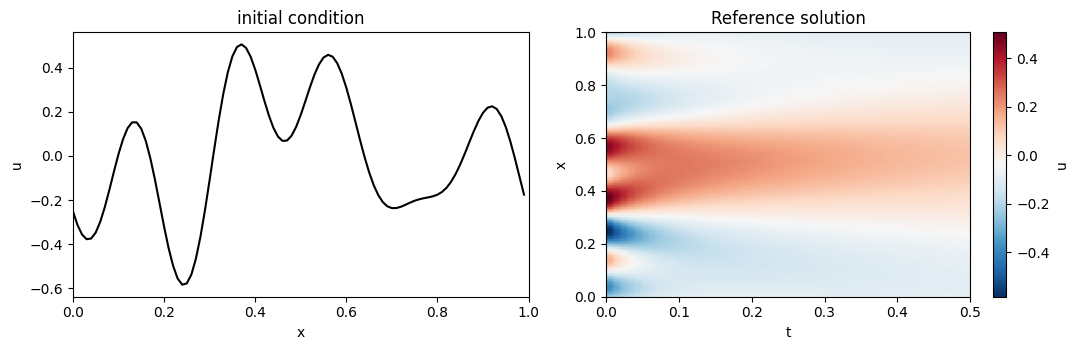

In [2]:
DATA_PATH = Path("burgers_solution_data.npz")

with np.load(DATA_PATH) as data:
    x_ref = jnp.asarray(data["x"])
    t_ref = jnp.asarray(data["t"])
    u_ref = jnp.asarray(data["u"])
    u0_ref = jnp.asarray(data["u0"])
    DOMAIN_EXTENT = float(data["domain_extent"])
    DT = float(data["dt"])
    DIFFUSIVITY = float(data["diffusivity"])
    FOURIER_CUTOFF = int(data["initial_condition_wavenumber_cutoff"])

T_FINAL = float(t_ref[-1])
NUM_POINTS = x_ref.size

print(f"u shape: {u_ref.shape}; domain: [0, {DOMAIN_EXTENT}); time: [0, {T_FINAL}]")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(x_ref, u0_ref, color="black")
axes[0].set(xlabel="x", ylabel="u", title="initial condition", xlim=[0,1])

axes[1].set(xlabel="t", ylabel="x", title="Reference solution")
image = axes[1].imshow( u_ref.T, origin="lower", aspect="auto", cmap="RdBu_r"
                       , extent=[0.0, T_FINAL, 0.0, DOMAIN_EXTENT] )

fig.colorbar(image, ax=axes[1], label="u")
fig.tight_layout()

## 3. A differentiable initial condition

Because the initial condition will be enforced through the network ansatz, the discrete Exponax snapshot must be converted into a continuous differentiable function. Its Fourier interpolant can
be evaluated at arbitrary collocation points and differentiated by JAX when constructing the spatial derivatives in the residual.

In [3]:
u0_fourier_coefficients = jnp.fft.fft(u0_ref) / NUM_POINTS
u0_fourier_wavenumbers = jnp.fft.fftfreq(NUM_POINTS, d=1.0 / NUM_POINTS)

def periodic_initial_condition(x):
    phase = 2j * jnp.pi * u0_fourier_wavenumbers * x / DOMAIN_EXTENT
    return jnp.real(jnp.sum(u0_fourier_coefficients * jnp.exp(phase)))

u0_interpolated = jax.vmap(periodic_initial_condition)(x_ref)
print("Maximum interpolation error:", float(jnp.max(jnp.abs(u0_interpolated - u0_ref))))

Maximum interpolation error: 4.023313522338867e-07


## 4. Periodic coordinate network

For a periodic domain, (x=0) and (x=L) represent the same physical point. A standard neural network does not know this because the raw inputs (0) and (L) are different. The trick is to replace the raw spatial coordinate by $(\sin(2\pi kx/L),\cos(2\pi kx/L))$. Consequently, the network and all its spatial derivatives would be periodic by construction.  Time is not periodic. It is only scaled to $[-1,1]$. This keeps the time input on a scale comparable to the sine and cosine features and usually improves training stability.  

In [4]:
NUM_FOURIER_MODES = FOURIER_CUTOFF

input_size = 1 + 2 * NUM_FOURIER_MODES
pinn = eqx.nn.MLP( in_size=input_size, out_size=1, width_size=64, depth=4, activation=jax.nn.tanh, key=jr.PRNGKey(1367) )

def periodic_coordinates(t, x):
    modes = jnp.arange(1, NUM_FOURIER_MODES + 1)
    phase = ( 2.0 * jnp.pi * modes * x / DOMAIN_EXTENT )
    scaled_time = ( 2.0 * t / T_FINAL - 1.0 )
    return jnp.concatenate([ jnp.asarray([scaled_time]), jnp.sin(phase), jnp.cos(phase) ] )

num_parameters = sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(pinn, eqx.is_array)))
print(f"Trainable parameters: {num_parameters:,}")

Trainable parameters: 13,313


## 5. Hard initial condition and PDE residual

We use the trial solution as given below:

$$u_\theta(t,x)=u_0(x)+\frac{t}{T}N_\theta(\phi(x),\tau(t)).$$

Therefore, the initial condition is satisfied exactly and does not require an additional initial-condition loss. The PDE residual is then obtained by differentiating the complete trial solution with respect to $x$ and $t$ using JAX automatic differentiation.

In [5]:
def trial_solution(model, t, x):
    model_inputs = periodic_coordinates(t, x)
    neural_output = model(model_inputs)[0]
    return periodic_initial_condition(x) + (t / T_FINAL) * neural_output

u_t = jax.grad(trial_solution, argnums=1)
u_x = jax.grad(trial_solution, argnums=2)
u_xx = jax.grad(u_x, argnums=2)

def pde_residual(model, t, x):
    u = trial_solution(model, t, x)
    return u_t(model, t, x) + u * u_x(model, t, x) - DIFFUSIVITY * u_xx(model, t, x)

batched_residual = jax.vmap(pde_residual, in_axes=(None, 0, 0))
batched_solution = jax.vmap(trial_solution, in_axes=(None, 0, 0))

# Sanity checks: hard initial and periodic constraints should hold before training
initial_error = jnp.max( jnp.abs(batched_solution(pinn, jnp.zeros_like(x_ref), x_ref) - u0_ref) )
probe_t = jnp.asarray(0.25)
periodic_value_error = jnp.abs(trial_solution(pinn, probe_t, 0.0) - trial_solution(pinn, probe_t, DOMAIN_EXTENT))
periodic_gradient_error = jnp.abs(u_x(pinn, probe_t, 0.0) - u_x(pinn, probe_t, DOMAIN_EXTENT))
print("Initial-condition max error:", float(initial_error))
print("Periodic value mismatch:", float(periodic_value_error))
print("Periodic gradient mismatch:", float(periodic_gradient_error))

Initial-condition max error: 4.023313522338867e-07
Periodic value mismatch: 2.682209014892578e-07
Periodic gradient mismatch: 3.337860107421875e-06


## 6. Collocation sampling and loss

Each optimization step samples a new uniform batch inside the space-time domain. `vmap` evaluates the scalar residual over the complete batch without writing a Python loop. Because the initial and periodic constraints are hard constraints, the total loss is simply

$$\mathcal{L}(\theta)=\frac{1}{N_r}\sum_{i=1}^{N_r}|r_\theta(t_i,x_i)|^2.$$

In [6]:
NUM_COLLOCATION_POINTS = 512
NUM_OPTIMIZATION_STEPS = 5_000
INITIAL_LEARNING_RATE  = 0.004
SAMPLING_SEED = 67

def sample_collocation_points(key, num_points):
    time_key, space_key = jr.split(key)
    t = jr.uniform(time_key, (num_points,), minval=0.0, maxval=T_FINAL)
    x = jr.uniform(space_key, (num_points,), minval=0.0, maxval=DOMAIN_EXTENT)
    return t, x

def loss_fn(model, t_collocation, x_collocation):
    residual = batched_residual(model, t_collocation, x_collocation)
    return jnp.mean(jnp.square(residual))

diagnostic_key = jr.PRNGKey(7)
diagnostic_t, diagnostic_x = sample_collocation_points(diagnostic_key, 512)
print("Initial diagnostic loss:", float(loss_fn(pinn, diagnostic_t, diagnostic_x)))

Initial diagnostic loss: 28.16010284423828


## 7. Optimization with Optax and Equinox

Adam is used with an exponentially decaying learning rate. The learning rate is multiplied by approximately 0.8 every 500 optimization steps, allowing larger updates early in training and smaller refinements later.

eqx.filter_value_and_grad computes the loss and differentiates it with respect to the trainable array-valued parameters of the model. eqx.filter_jit compiles the complete update step, including loss evaluation, automatic differentiation, and the Adam update.

New collocation points are sampled outside the compiled function at every iteration. This keeps the random-key flow explicit while allowing the compiled optimization step to be reused as long as the input shapes remain unchanged.

In [7]:
learning_rate_schedule = optax.exponential_decay( init_value=INITIAL_LEARNING_RATE, transition_steps=500, decay_rate=0.8 )
optimizer = optax.adam(learning_rate_schedule)
opt_state = optimizer.init(eqx.filter(pinn, eqx.is_array))

@eqx.filter_jit
def make_step(model, state, t_collocation, x_collocation):
    loss, grads = eqx.filter_value_and_grad(loss_fn)(model, t_collocation, x_collocation)
    updates, new_state = optimizer.update(grads, state, model)
    new_model = eqx.apply_updates(model, updates)
    return new_model, new_state, loss

sampling_key = jr.PRNGKey(SAMPLING_SEED)
loss_history = []

for step in range(NUM_OPTIMIZATION_STEPS):
    sampling_key, batch_key = jr.split(sampling_key)
    t_collocation, x_collocation = sample_collocation_points( batch_key, NUM_COLLOCATION_POINTS )
    pinn, opt_state, loss = make_step( pinn, opt_state, t_collocation, x_collocation )
    loss_history.append(float(loss))

    if step % 1_000 == 0 or step == NUM_OPTIMIZATION_STEPS - 1:
        print(f"Step {step:5d} | residual MSE = {float(loss):.3e}")

Step     0 | residual MSE = 2.951e+01
Step  1000 | residual MSE = 8.734e-03
Step  2000 | residual MSE = 4.265e-03
Step  3000 | residual MSE = 1.766e-03
Step  4000 | residual MSE = 1.232e-03
Step  4999 | residual MSE = 1.008e-03


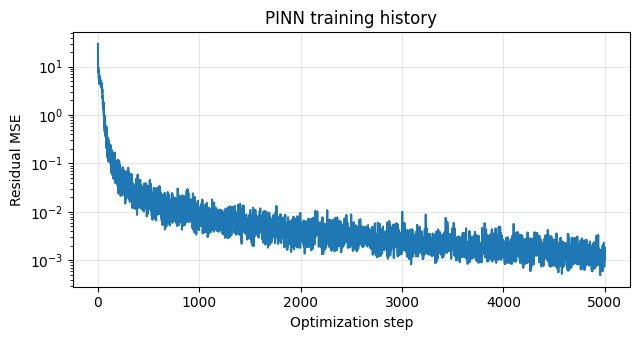

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.semilogy(loss_history)
ax.set(xlabel="Optimization step", ylabel="Residual MSE", title="PINN training history")
ax.grid(alpha=0.3) 
fig.tight_layout()

## 8. Evaluate on the Exponax grid

The following cells are the first place where reference trajectory values beyond $t=0$ are used. We report the space-time relative $L_2$ error, normalized RMSE versus time, and a residual estimate on a fresh random point set. A low training loss alone is not sufficient evidence of solution accuracy.

In [9]:
time_mesh, space_mesh = jnp.meshgrid(t_ref, x_ref, indexing="ij")
u_pinn = batched_solution( pinn, time_mesh.ravel(), space_mesh.ravel() ).reshape(u_ref.shape)

relative_l2 = jnp.linalg.norm(u_pinn - u_ref) / jnp.linalg.norm(u_ref)
nrmse_vs_time = ( jnp.sqrt(jnp.mean(jnp.square(u_pinn - u_ref), axis=1)) / (jnp.sqrt(jnp.mean(jnp.square(u_ref), axis=1)) + 1e-12) )

test_key = jr.PRNGKey(2026)
test_t, test_x = sample_collocation_points(test_key, 4_096)
held_out_residual_rms = jnp.sqrt( jnp.mean(jnp.square(batched_residual(pinn, test_t, test_x))) )

print(f"Space-time relative L2 error: {float(relative_l2):.3e}")
print(f"Final-time nRMSE:           {float(nrmse_vs_time[-1]):.3e}")
print(f"Held-out residual RMS:      {float(held_out_residual_rms):.3e}")

Space-time relative L2 error: 7.179e-03
Final-time nRMSE:           1.648e-02
Held-out residual RMS:      3.667e-02


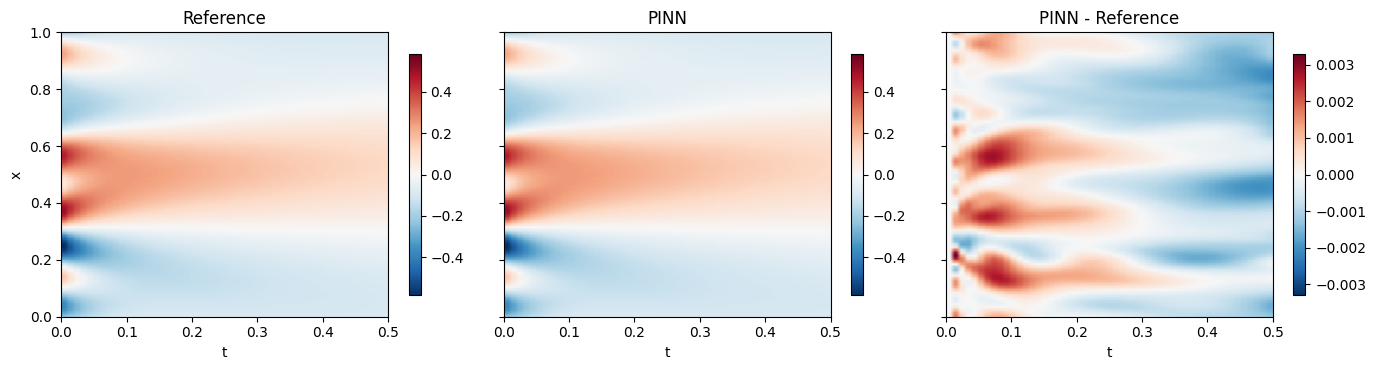

In [ ]:
error_limit = float(jnp.max(jnp.abs(u_pinn - u_ref)))
field_limit = float(jnp.max(jnp.abs(u_ref)))
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharex=True, sharey=True)

plots = [
    (u_ref, "Reference", "RdBu_r", -field_limit, field_limit),
    (u_pinn, "PINN", "RdBu_r", -field_limit, field_limit),
    (u_pinn - u_ref, "PINN - Reference", "RdBu_r", -error_limit, error_limit),
]
for ax, (field, title, cmap, vmin, vmax) in zip(axes, plots):
    image = ax.imshow(
        field.T, origin="lower", aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax,
        extent=[0.0, T_FINAL, 0.0, DOMAIN_EXTENT],
    )
    ax.set(xlabel="t", title=title)
    fig.colorbar(image, ax=ax, shrink=0.85)
axes[0].set_ylabel("x")
fig.tight_layout()

# plt.savefig("pinn_comparison.png", dpi=700)

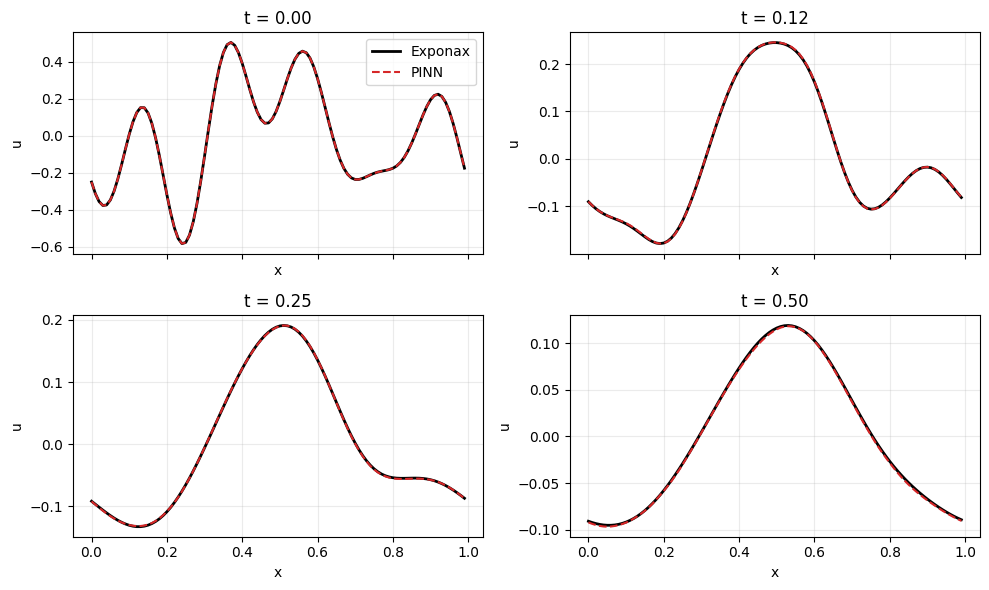

In [11]:
snapshot_indices = [0, len(t_ref) // 4, len(t_ref) // 2, -1]
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
for ax, index in zip(axes.ravel(), snapshot_indices):
    ax.plot(x_ref, u_ref[index], color="black", lw=2, label="Exponax")
    ax.plot(x_ref, u_pinn[index], color="tab:red", ls="--", label="PINN")
    ax.set(title=f"t = {float(t_ref[index]):.2f}", xlabel="x", ylabel="u")
    ax.grid(alpha=0.25)
axes[0, 0].legend()
fig.tight_layout()

## Reference

Problem parameters and reference-data generation follow the [Exponax 1D Burgers Emulator Training](https://fkoehler.site/exponax/examples/learning_burgers_autoregressive_neural_operator/) example. The original example trains a supervised convolutional time-stepper; this notebook intentionally changes the learning formulation to a physics-informed coordinate network.